In [1]:
# Step 1: Install & import libraries
!pip install scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score

%matplotlib inline

In [2]:
# Step 2: Load the dataset
url = "https://www.kaggleusercontent.com/datasets/mlg-ulb/creditcardfraud.zip?filename=creditcard.csv"
# Colab requires you to upload manually or mount drive if download fails
from google.colab import files
uploaded = files.upload()  # Upload the CSV you downloaded from Kaggle

df = pd.read_csv(next(iter(uploaded)))
df.head()

Saving archive.zip to archive.zip


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


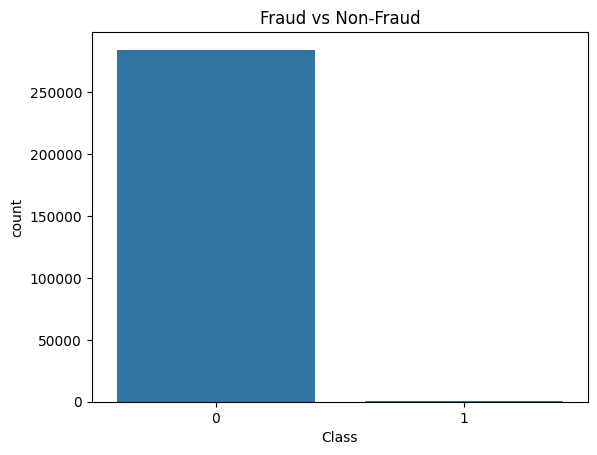

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

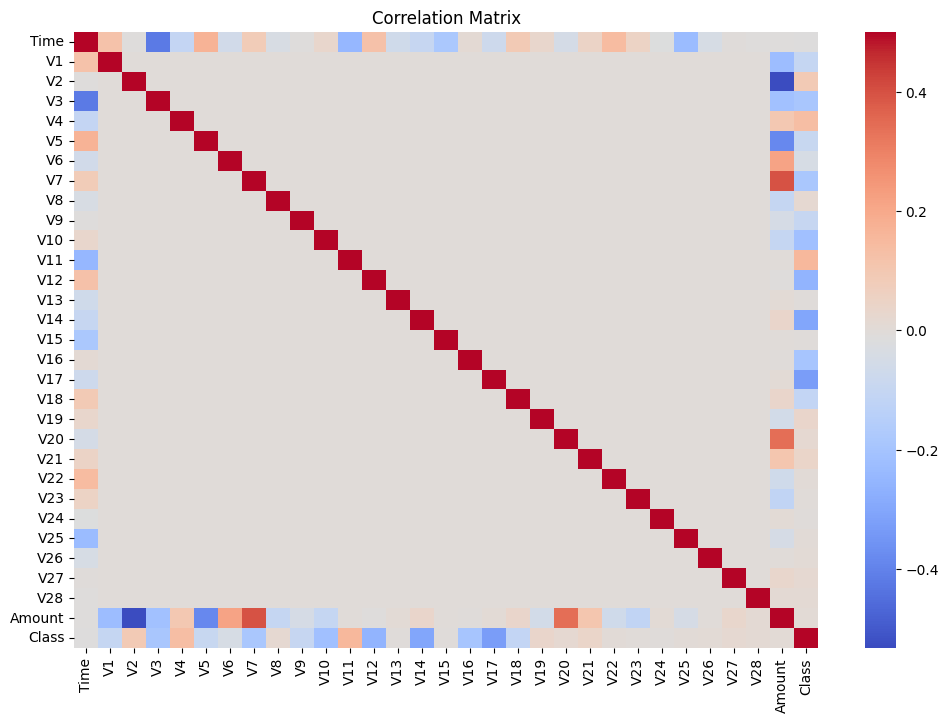

In [3]:
# Step 3: Exploratory Data Analysis (EDA)

# Check dataset shape & class distribution
print(df.shape)
print(df['Class'].value_counts())

# Plot class imbalance
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

# Summary stats
print(df.describe())

# Check correlation (optional)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", vmax=0.5)
plt.title("Correlation Matrix")
plt.show()

In [4]:
# Step 4: Split data into features and labels
X = df.drop('Class', axis=1)
y = df['Class']

# Train-test split (stratify to keep imbalance ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Step 5: Baseline Random Forest Model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')  # handle imbalance
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]  # probability scores

In [6]:
# Step 6: Evaluate Baseline Model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = rf.score(X_test, y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

Confusion Matrix:
[[56861     3]
 [   25    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy: 0.9995
Precision: 0.9605
Recall: 0.7449
F1-score: 0.8391
ROC-AUC: 0.9529


In [7]:
# Step 7: Show effect of "changing the dials" (Decision Threshold)
thresholds = [0.5, 0.4, 0.3, 0.2]
for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(f"Precision: {precision_score(y_test, y_pred_thresh):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_thresh):.4f}")
    print(f"F1-score: {f1_score(y_test, y_pred_thresh):.4f}")


Threshold = 0.5
Precision: 0.9605
Recall: 0.7449
F1-score: 0.8391

Threshold = 0.4
Precision: 0.9518
Recall: 0.8061
F1-score: 0.8729

Threshold = 0.3
Precision: 0.9222
Recall: 0.8469
F1-score: 0.8830

Threshold = 0.2
Precision: 0.8571
Recall: 0.8571
F1-score: 0.8571


In [8]:
# Step 8: Hyperparameter tuning example (optional)
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:,1]

print("Tuned Random Forest Metrics:")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")

Tuned Random Forest Metrics:
Precision: 0.7736
Recall: 0.8367
F1-score: 0.8039


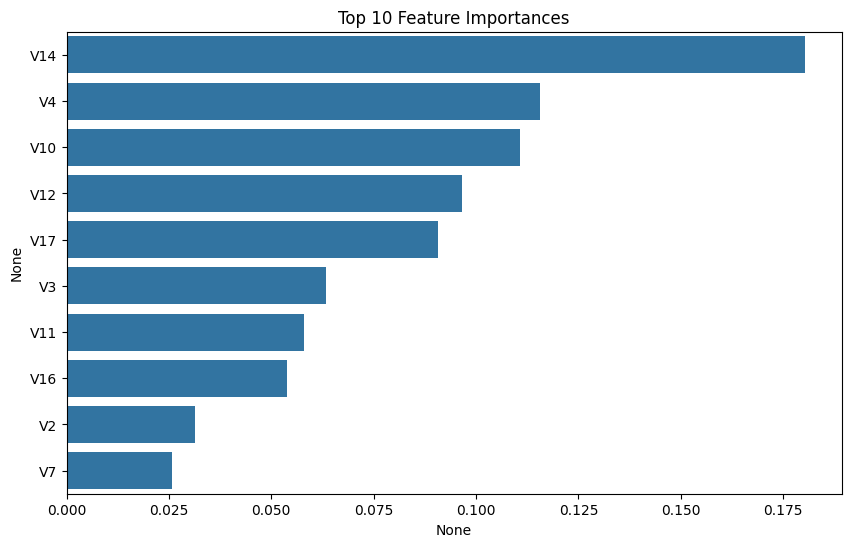

In [9]:
# Step 9: Feature importance (to explain model to stakeholders)
importances = rf_tuned.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10])
plt.title("Top 10 Feature Importances")
plt.show()